<a href="https://colab.research.google.com/github/seungc1/AivleSchool/blob/main/Supervisor_Critic_%EA%B5%AC%EC%A1%B0%EB%A5%BC_%ED%99%9C%EC%9A%A9%ED%95%9C_%EB%B6%84%EC%84%9D_%EC%9E%90%EB%8F%99%ED%99%94_%EB%B0%8F_%ED%92%88%EC%A7%88_%EA%B3%A0%EB%8F%84%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 워크플로우

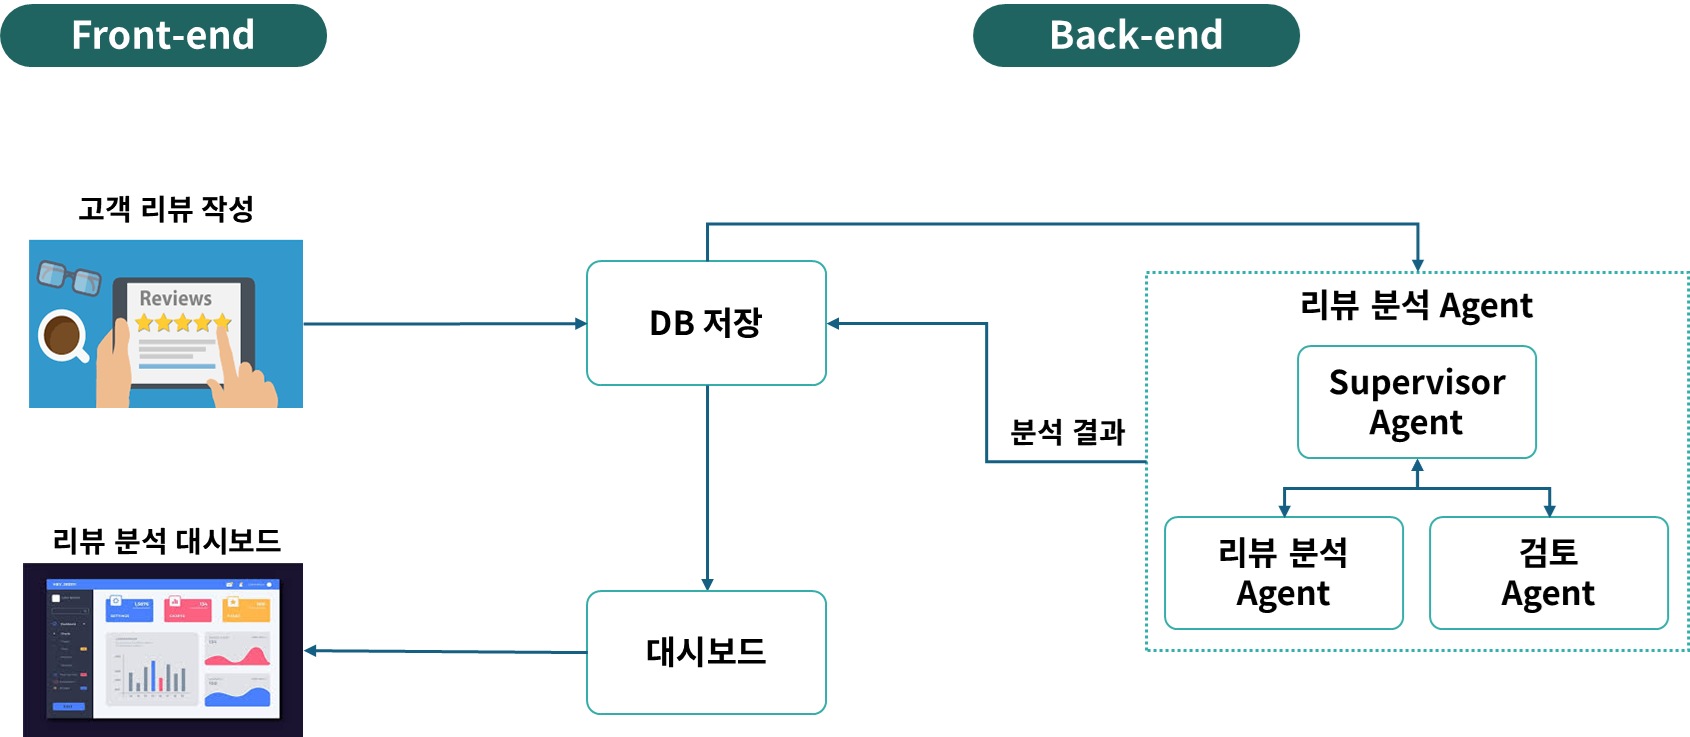

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj2_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install -q langchain-openai langchain-community streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.0 which is incompatible.


* 라이브러리 로딩

In [ ]:
# 기본 제공 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# 더 필요한 라이브러리가 있다면 추가합시다. -----




/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### (3) OpenAI API Key 확인

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj2_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

In [ ]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-proj-s4iySMPDq8uh1ga99KDglK


## **2. 미션③ : langsmith 기반 운영 시스템**

* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석

### **(1) langsmith 설정**

* langsmith trace에 project 추가 : `proj2_agent`


* 운영환경 설정

In [ ]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "proj2_agent"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

### **(2) Step1 결과물**
* Step1의 결과물을 아래 붙여 넣습니다.

#### **1) State & LLM 준비**

In [ ]:
class ReviewState(TypedDict):
    # 입력 리뷰
    messages: Annotated[list, add_messages]
    review_text: str

    # 개별 에이전트 실행 결과
    extracted_attributes: Optional[dict]
    inspection_decision: Optional[Literal["APPROVED", "REJECTED"]]
    inspection_reason: Optional[str]

    # 흐름 제어
    next_step: Optional[str]
    iteration: int
    max_iterations: int

* llm 준비

In [ ]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0.3
)

#### **2) Agent 노드 준비**
* 필요 Agent : Analyzer Agent, Critic Agent, Supervisor Agent
* 리뷰 결과 State에 담기게 되는 형식 : Dictionary(혹은 JSON)


* Analyzer Agent

In [ ]:
def analyzer_node(state: ReviewState):
    system_prompt = """
    당신은 화장품 리뷰 분석 전문가입니다.
    입력된 리뷰에서 핵심 속성(보습, 가격, 향, 포장 순서보장)을 추출하고,
    각 속성별 세부 감성(긍정/부정) 및 그렇게 판단한 요인을 분석하세요.

    반드시 JSON 형식으로 출력해야 합니다.
    예시: {"보습력": {"sentiment": "긍정", "reason": "하루 종일 촉촉함"}}
    """

    user_content = f"리뷰 내용: {state['review_text']}"
    if state.get('inspection_reason'):
        user_content += f"\n이전 검토 피드백(반영 필요): {state['inspection_reason']}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    # JSON 출력을 강제하기 위해 bind 사용 혹은 prompt에 명시
    response = llm.invoke(messages)

    try:
        # 문자열에서 JSON 부분만 추출하여 파싱
        content = response.content
        json_start = content.find('{')
        json_end = content.rfind('}') + 1
        extracted_data = json.loads(content[json_start:json_end])
    except Exception as e:
        extracted_data = {"error": "JSON parsing failed", "raw": response.content}

    return {"extracted_attributes": extracted_data}

* Critic Agent

In [ ]:
def critic_node(state: ReviewState):
    # 1. 비평가 에이전트의 역할과 검수 기준을 정의하는 시스템 프롬프트 설정
    system_prompt = """
    당신은 화장품 리뷰 분석 결과의 품질을 검수하는 비평가 에이전트입니다.
    아래 검수 기준을 바탕으로 분석 결과의 승인(APPROVED) 또는 거절(REJECTED) 여부를 판단하세요.

    [검수 기준]
    1. 화장품과 전혀 관련 없는 리뷰(예: 음식점, 가전 등)인 경우, 즉시 REJECTED로 판단하고 사유의 시작 부분에 반드시 "[관련없음]" 이라는 태그를 포함하세요.
    2. JSON 스키마 규격 준수 여부 확인
    3. 역설적 표현(예: '비싸지만 좋다')의 오분류 여부, 다중 감성 누락 여부 검증
    4. 할루시네이션(리뷰에 없는 내용 지어냄) 방지 검사

    [출력 형식]
    반드시 JSON 형식으로 출력하세요:
    {
        "inspection_decision": "APPROVED" 또는 "REJECTED",
        "inspection_reason": "거절 시 상세 사유 작성 (승인 시 빈 문자열)"
    }
    """

    # 2. 분석을 위해 원본 리뷰와 분석가가 추출한 속성 데이터를 사용자 컨텐츠로 구성
    user_content = f"""
    [원본 리뷰]
    {state['review_text']}

    [추출된 분석 결과]
    {json.dumps(state['extracted_attributes'], ensure_ascii=False)}
    """

    # 3. 메시지 리스트 구성 및 LLM 호출
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    response = llm.invoke(messages)

    # 4. LLM 응답에서 JSON 데이터를 추출하고 파싱
    try:
        content = response.content
        json_start = content.find('{')
        json_end = content.rfind('}') + 1
        result = json.loads(content[json_start:json_end])
    except Exception as e:
        # 파싱 실패 시 거절 처리
        result = {
            "inspection_decision": "REJECTED",
            "inspection_reason": f"Critic output parsing failed: {str(e)}"
        }

    # JSON 파싱 결과에서 검수 결정(APPROVED/REJECTED) 값을 안전하게 추출 (키가 없으면 REJECTED 처리)
    inspection_decision = result.get("inspection_decision", "REJECTED")
    # JSON 파싱 결과에서 거절 사유 등 검토 의견을 안전하게 추출 (키가 없으면 빈 문자열 처리)
    inspection_reason = result.get("inspection_reason", "")

    # 5. 검수 결과(결정 및 사유)를 반환하여 State 업데이트
    update_data = {
        "inspection_decision": inspection_decision,
        "inspection_reason": inspection_reason
    }

    # 화장품과 관련없는 리뷰의 경우 반복 없이 즉시 종료하기 위해 iteration을 최대치로 덮어씌움
    if "[관련없음]" in inspection_reason:
        update_data["iteration"] = state.get("max_iterations", 3)

    return update_data

* Supervisor Agent

In [ ]:
def supervisor_node(state: ReviewState):
    # 1. 현재 반복 횟수 및 최대 반복 횟수 확인
    current_iteration = state.get('iteration', 0)
    max_iterations = state.get('max_iterations', 3)

    # 2. 비평가의 결정 확인 (APPROVED / REJECTED)
    decision = state.get('inspection_decision')

    # 3. 다음 단계(next_step) 결정 로직
    if decision == "APPROVED":
        # 승인(APPROVED)되면 최대 반복 횟수와 상관없이 바로 결과로 넘어감(종료)
        next_step = END
    elif decision == "REJECTED":
        if current_iteration < max_iterations:
            # 아직 반복 가능하면 분석가(Analyzer)에게 재요청
            next_step = "Analysis"
        else:
            # 최대 반복 횟수 초과 시 강제 종료
            next_step = END
    else:
        # 결정 데이터가 없는 경우 (최초 시작 혹은 분석 완료 직후)
        if state.get('extracted_attributes'):
            next_step = "Inspection"
        else:
            next_step = "Analysis"

    # 4. 반복 횟수 업데이트 및 다음 단계 저장
    return {
        "next_step": next_step,
        "iteration": current_iteration + 1
    }

#### **3) 그래프 구성**

* route_next 함수

In [ ]:
def route_next(state: ReviewState):
    # supervisor_node에서 결정한 next_step 값을 확인하여 라우팅
    next_step = state.get("next_step")

    if next_step == "Analysis":
        return "analyzer"
    elif next_step == "Inspection":
        return "critic"
    else:
        return END

* 그래프

In [ ]:
workflow = StateGraph(ReviewState)

# 1. 노드 추가: 분석가, 비평가, 관리자 노드 등록
workflow.add_node("analyzer", analyzer_node)
workflow.add_node("critic", critic_node)
workflow.add_node("supervisor", supervisor_node)

# 2. 엣지 연결: 시작점에서 바로 supervisor로 이동
workflow.add_edge(START, "supervisor")

# 3. 조건부 엣지: supervisor의 판단에 따라 analyzer, critic으로 분기하거나 종료
# 'End' 키 대신 실제 반환값인 END (또는 '__end__')를 키로 사용해야 합니다.
workflow.add_conditional_edges("supervisor", route_next,
                               {"analyzer": "analyzer", "critic": "critic",
                               END: END})

# 4. 순환 연결: 각 작업 완료 후 다시 supervisor에게 보고
workflow.add_edge("analyzer", "supervisor")
workflow.add_edge("critic", "supervisor")

# 5. 그래프 컴파일: 실행 가능한 형태로 변환
app = workflow.compile()

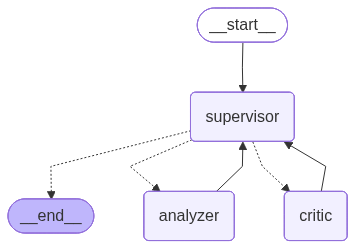

In [ ]:
app

### **(3) 추적 확인**

예제 코드를 통해 추적을 확인해 봅시다.


In [ ]:
initial_state = {
    "messages": [],
    "review_text": "발림성이 좋고 촉촉해서 만족해요. 다만 가격은 조금 비싼 편이에요.",
    "extracted_attributes": None,
    "inspection_decision": None,
    "inspection_reason": None,
    "next_step": None,
    "iteration": 0,
    "max_iterations": 3
}

result = app.invoke(initial_state)

result

{'messages': [],
 'review_text': '발림성이 좋고 촉촉해서 만족해요. 다만 가격은 조금 비싼 편이에요.',
 'extracted_attributes': {'보습': {'sentiment': '긍정',
   'reason': '발림성이 좋고 촉촉해서 만족함'},
  '가격': {'sentiment': '부정', 'reason': '가격이 조금 비싼 편임'}},
 'inspection_decision': 'APPROVED',
 'inspection_reason': '',
 'next_step': '__end__',
 'iteration': 3,
 'max_iterations': 3}

## **3. 미션④ : Agent 고도화**

* [필수] Supervisor 중심 반복 제어
    - LLM 기반 흐름 제어
    - reason_code 기반 재시도 정책
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### **(1) Supervisor 중심 반복 제어**

* Supervisor Agent : 통제 정책 오케스트레이터(Policy Orchestrator)
    * Critic 판정이 ‘부적합’ 일 때 LLM은
        * critic_reason을 확인하여 reason_code 분류
        * 재시도 시 필요한 짧은 수정 지시를 repair_directive에 저장


#### **1) State 보완**

In [ ]:
ReasonCode = Literal["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"]

class ReviewState(TypedDict):
    # 입력 리뷰
    messages: Annotated[list, add_messages]
    review_text: str

    # 개별 에이전트 실행 결과
    extracted_attributes: Optional[dict]
    inspection_decision: Optional[Literal["APPROVED", "REJECTED"]]
    inspection_reason: Optional[str]
    reason_code: Optional[ReasonCode]

    # 흐름 제어
    next_step: Optional[str]
    iteration: int
    max_iterations: int

    reason_code: Optional[ReasonCode]     # 에러 분류 코드
    repair_directive: Optional[str]      # 재시도 시 수정 지시문

In [ ]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0.3
)

#### **2) Agent 노드 준비**

In [ ]:
# 정책 및 필요 함수 준비 : 아래 내용을 수정해서 사용하세요.

REASON_CODES = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"}
RETRYABLE = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR"}

REPAIR_TEMPLATES = {
    "OUTPUT_ERROR": "dict 1개만 출력. 코드블록/설명 없이 items 구조와 label(0/1)을 맞춰라.",
    "SCOPE_ERROR": "aspect는 보습, 가격, 향, 포장만 사용하라. 다른 표현은 가장 가까운 값으로 매핑하라.",
    "EVIDENCE_ERROR": "evidence는 리뷰 원문에 실제로 있는 연속된 문구만 사용하라.",
    "QUALITY_ERROR": "리뷰에 없는 내용을 만들지 말고, 애매하면 해당 aspect는 제외하라."
}

# 딕셔너리 파싱 함
def parse_dict(text, default):
    try:
        return ast.literal_eval(text)
    except:
        return default

* Analyzer Agents 보완

In [ ]:
def analyzer_node(state: ReviewState):
    system_prompt = """
    당신은 화장품 상품 리뷰 분석 전문가입니다.

    입력된 리뷰에서 화장품과 관련된 핵심 속성을 추출하세요.
    각 속성별로 감성(sentiment), 판단 이유(reason), 원문 근거(evidence)를 분석하세요.

    [분석 대상 속성 예시]
    - 보습
    - 발림성
    - 흡수력
    - 향
    - 자극감
    - 피부반응
    - 가격
    - 용량
    - 포장
    - 배송
    - 재구매의사

    [규칙]
    1. 리뷰에 실제로 언급된 내용만 추출하세요.
    2. 원문에 없는 내용을 추측해서 만들지 마세요.
    3. 감성은 "긍정", "부정", "중립" 중 하나로 작성하세요.
    4. evidence에는 원문에서 근거가 되는 짧은 표현을 넣으세요.
    5. 반드시 JSON 형식으로만 출력하세요.

    [출력 예시]
    {
      "보습": {
        "sentiment": "긍정",
        "reason": "촉촉함이 만족스럽다고 표현했기 때문",
        "evidence": "촉촉해서 만족해요"
      },
      "가격": {
        "sentiment": "부정",
        "reason": "가격이 비싸다고 언급했기 때문",
        "evidence": "가격은 조금 비싼 편이에요"
      }
    }
    """

    user_content = f"리뷰 내용: {state['review_text']}"
    if state.get('inspection_reason'):
        user_content += f"\n이전 검토 피드백(반영 필요): {state['inspection_reason']}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    response = llm.invoke(messages)

    try:
        content = response.content
        json_start = content.find('{')
        json_end = content.rfind('}') + 1
        extracted_data = json.loads(content[json_start:json_end])
    except Exception as e:
        extracted_data = {"error": "JSON parsing failed", "raw": response.content}

    return {"extracted_attributes": extracted_data}

* Critic Agent 보완

In [ ]:
def critic_node(state: ReviewState):
    system_prompt = """
    당신은 화장품 리뷰 분석 결과의 품질을 검수하는 비평가 에이전트입니다.
    아래 검수 기준을 바탕으로 분석 결과의 승인(APPROVED) 또는 거절(REJECTED) 여부를 판단하세요.

    [검수 기준]
    1. 화장품과 전혀 관련 없는 리뷰(예: 음식점, 가전, 음식 배달 등)인 경우 REJECTED로 판단하세요.
    2. JSON 스키마 규격을 준수하는지 확인하세요.
       - 각 속성에는 sentiment, reason, evidence가 있어야 합니다.
    3. sentiment는 반드시 "긍정", "부정", "중립" 중 하나여야 합니다.
    4. evidence가 원본 리뷰에 실제로 존재하는 표현인지 확인하세요.
    5. 원본 리뷰에 없는 내용을 지어낸 경우 REJECTED로 판단하세요.
    6. 중요한 감성이나 속성이 누락된 경우 REJECTED로 판단하세요.

    [reason_code 기준]
    - OK: 문제가 없어 승인할 수 있음
    - OUTPUT_ERROR: JSON 형식 오류 또는 필수 필드 누락
    - SCOPE_ERROR: 화장품 리뷰가 아님
    - EVIDENCE_ERROR: 원문에 없는 내용 생성 또는 evidence가 원문에 없음
    - QUALITY_ERROR: 분석 품질 부족, 감성 오분류, 중요한 속성 누락

    [출력 형식]
    반드시 JSON 형식으로만 출력하세요:
    {
        "inspection_decision": "APPROVED" 또는 "REJECTED",
        "inspection_reason": "거절 시 상세 사유 작성, 승인 시 빈 문자열",
        "reason_code": "OK 또는 OUTPUT_ERROR 또는 SCOPE_ERROR 또는 EVIDENCE_ERROR 또는 QUALITY_ERROR"
    }
    """

    user_content = f"""
    [원본 리뷰]
    {state['review_text']}

    [추출된 분석 결과]
    {json.dumps(state['extracted_attributes'], ensure_ascii=False)}
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    response = llm.invoke(messages)

    try:
        content = response.content
        json_start = content.find('{')
        json_end = content.rfind('}') + 1
        result = json.loads(content[json_start:json_end])
    except Exception as e:
        result = {
            "inspection_decision": "REJECTED",
            "inspection_reason": f"Critic output parsing failed: {str(e)}",
            "reason_code": "OUTPUT_ERROR"
        }

    inspection_decision = result.get("inspection_decision", "REJECTED")
    inspection_reason = result.get("inspection_reason", "")
    reason_code = result.get("reason_code", "QUALITY_ERROR")

    # 승인인데 reason_code가 OK가 아니면 보정
    if inspection_decision == "APPROVED":
        reason_code = "OK"
        inspection_reason = ""

    # 거절인데 reason_code가 OK면 품질 오류로 보정
    if inspection_decision == "REJECTED" and reason_code == "OK":
        reason_code = "QUALITY_ERROR"

    update_data = {
        "inspection_decision": inspection_decision,
        "inspection_reason": inspection_reason,
        "reason_code": reason_code
    }

    # 화장품과 관련 없는 리뷰면 반복하지 않고 종료시키기 위해 iteration을 max로 설정
    if reason_code == "SCOPE_ERROR":
        update_data["iteration"] = state.get("max_iterations", 3)

    return update_data

* Supervisor Agent 보완

In [ ]:
def supervisor_node(state: ReviewState):
    # 1. 현재 반복 횟수 및 최대 반복 횟수 확인
    current_iteration = state.get("iteration", 0)
    max_iterations = state.get("max_iterations", 3)

    # 2. Critic 결과 확인
    decision = state.get("inspection_decision")
    reason_code = state.get("reason_code")

    # 3. 다음 단계 결정
    if decision == "APPROVED" or reason_code == "OK":
        # 승인되면 바로 종료
        next_step = END

    elif reason_code == "SCOPE_ERROR":
        # 화장품 리뷰가 아니면 다시 분석해도 의미 없으므로 종료
        next_step = END

    elif decision == "REJECTED":
        # 형식 오류, 근거 오류, 품질 오류는 반복 가능하면 Analyzer에게 재분석 요청
        if current_iteration < max_iterations:
            next_step = "Analysis"
        else:
            next_step = END

    else:
        # 아직 Critic 판단이 없는 경우
        if state.get("extracted_attributes"):
            next_step = "Inspection"
        else:
            next_step = "Analysis"

    # 4. iteration 업데이트
    # END로 갈 때는 굳이 반복 횟수를 더 올리지 않고,
    # 재분석/검수로 넘어갈 때만 증가시킴
    if next_step == END:
        new_iteration = current_iteration
    else:
        new_iteration = current_iteration + 1

    return {
        "next_step": next_step,
        "iteration": new_iteration
    }

* route_next 함수

In [ ]:
def route_next(state: ReviewState):
    # supervisor_node에서 결정한 next_step 값을 확인하여 라우팅
    next_step = state.get("next_step")

    if next_step == "Analysis":
        return "analyzer"
    elif next_step == "Inspection":
        return "critic"
    else:
        return END

* 그래프

In [ ]:
workflow = StateGraph(ReviewState)

# 1. 노드 추가: 분석가, 비평가, 관리자 노드 등록
workflow.add_node("analyzer", analyzer_node)
workflow.add_node("critic", critic_node)
workflow.add_node("supervisor", supervisor_node)

# 2. 엣지 연결: 시작점에서 바로 supervisor로 이동
workflow.add_edge(START, "supervisor")

# 3. 조건부 엣지: supervisor의 판단에 따라 analyzer, critic으로 분기하거나 종료
# 'End' 키 대신 실제 반환값인 END (또는 '__end__')를 키로 사용해야 합니다.
workflow.add_conditional_edges("supervisor", route_next,
                               {"analyzer": "analyzer", "critic": "critic",
                               END: END})

# 4. 순환 연결: 각 작업 완료 후 다시 supervisor에게 보고
workflow.add_edge("analyzer", "supervisor")
workflow.add_edge("critic", "supervisor")

# 5. 그래프 컴파일: 실행 가능한 형태로 변환
app = workflow.compile()

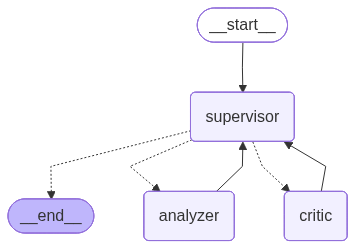

In [ ]:
app

* 실행 테스트

In [ ]:
initial_state = {
    "messages": [],
    "review_text": "발림성이 좋고 촉촉해서 만족해요. 다만 가격은 조금 비싼 편이에요.",
    "extracted_attributes": None,
    "inspection_decision": None,
    "inspection_reason": None,
    "reason_code": None,
    "next_step": None,
    "iteration": 0,
    "max_iterations": 3
}

result = app.invoke(initial_state)

result

{'messages': [],
 'review_text': '발림성이 좋고 촉촉해서 만족해요. 다만 가격은 조금 비싼 편이에요.',
 'extracted_attributes': {'발림성': {'sentiment': '긍정',
   'reason': '발림성이 좋다고 직접 언급했기 때문',
   'evidence': '발림성이 좋고'},
  '보습': {'sentiment': '긍정',
   'reason': '촉촉해서 만족한다고 표현했기 때문',
   'evidence': '촉촉해서 만족해요'},
  '가격': {'sentiment': '부정',
   'reason': '가격이 조금 비싼 편이라고 언급했기 때문',
   'evidence': '가격은 조금 비싼 편이에요'}},
 'inspection_decision': 'APPROVED',
 'inspection_reason': '',
 'reason_code': 'OK',
 'next_step': '__end__',
 'iteration': 2,
 'max_iterations': 3}

### **(2) DB에 쌓인 리뷰 예측 batch 처리**

* 리뷰 데이터 여러 건을 임의로 생성하여 Step1에서 생성한 DB의 테이블에 저장.
* DB에서 분석 대상 리뷰 조회(예: agent_aspect가 NULL인 데이터)
* 각 리뷰에 대해 Agent 실행
* 분석 결과(items)에서 aspect , label 추출
* DB에 결과 저장 (UPDATE)


#### **1) 데이터 준비**
* data.csv 파일 로딩
* review 칼럼의 값만 DB에 저장

In [ ]:
# 코랩에 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
import os
import pandas as pd
import sqlite3

# 업로드한 파일 이름 자동 가져오기
csv_filename = list(uploaded.keys())[0]

# CSV 읽기
df = pd.read_csv(csv_filename)

# review 컬럼만 사용
reviews = df[["review"]].dropna()

# DB 저장 경로: 대시보드 app.py와 같은 경로를 사용
project_dir = "/content/drive/MyDrive/proj2_agent"
os.makedirs(project_dir, exist_ok=True)
db_path = os.path.join(project_dir, "reviews.db")

# DB 연결
conn = sqlite3.connect(db_path)
cur = conn.cursor()

# 기존 테이블 완전 삭제
cur.execute("DROP TABLE IF EXISTS reviews")
conn.commit()

# 새 테이블 생성
cur.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    review TEXT,
    agent_aspect TEXT,
    agent_label TEXT,
    agent_result TEXT
)
""")
conn.commit()

# review 값만 DB에 저장하고 결과 컬럼은 NULL
for review in reviews["review"]:
    cur.execute("""
    INSERT INTO reviews (review, agent_aspect, agent_label, agent_result)
    VALUES (?, NULL, NULL, NULL)
    """, (review,))

conn.commit()
conn.close()

print(f"{len(reviews)}개 리뷰를 DB에 저장했습니다.")
print(f"DB 저장 위치: {db_path}")

200개 리뷰를 DB에 저장했습니다.
DB 저장 위치: /content/drive/MyDrive/proj2_agent/reviews.db


In [ ]:
conn = sqlite3.connect(db_path)
cur = conn.cursor()
cur.execute("""
INSERT INTO reviews (review) VALUES
('배송이 너무 늦게 왔고 박스도 찌그러져 있어서 기분이 좋지 않았습니다.'),
('주문한 상품이 아니라 다른 제품이 와서 오배송 처리 요청했습니다.'),
('뚜껑이 제대로 닫혀 있지 않았는지 내용물이 새서 왔습니다.'),
('사용하고 나서 얼굴에 붉은기가 올라오고 따가움이 심했습니다.'),
('처음 발랐을 때는 괜찮았는데 다음 날 피부 트러블이 생겼습니다.'),
('제품 용기가 깨져서 도착했고 내용물도 일부 흘러 있었습니다.'),
('포장이 허술해서 그런지 상품이 파손된 상태로 배송되었습니다.'),
('민감성 피부인데 사용 후 가려움과 자극이 느껴져서 중단했습니다.'),
('상품 일부가 누락되어 배송됐습니다. 다시 확인 부탁드립니다.'),
('냄새가 이상하고 변질된 것 같아서 사용하기 불안합니다.'),
('유통기한이 너무 짧은 제품이 와서 환불 요청하고 싶습니다.'),
('사용 후 알레르기 반응처럼 피부가 붉게 올라왔습니다.'),
('제품 펌프가 고장 나서 내용물이 제대로 나오지 않습니다.'),
('받자마자 용기 입구가 깨져 있어서 교환 신청했습니다.'),
('발랐더니 얼굴이 화끈거리고 자극이 강해서 바로 씻어냈습니다.'),
('배송된 상품이 사진과 다르고 다른 제품처럼 보여서 반품하고 싶습니다.'),
('제품 안에 이물질처럼 보이는 것이 있어서 사용하지 못했습니다.'),
('포장 안에 본품이 빠져 있고 사은품만 들어 있었습니다.'),
('한 번 사용했는데 피부가 뒤집어져서 다시는 구매하지 않을 것 같습니다.'),
('상품 상태가 불량이고 고객센터 문의 후 환불 진행하고 싶습니다.');
""")
conn.commit()
conn.close()

In [ ]:
conn = sqlite3.connect(db_path)

check_df = pd.read_sql_query("SELECT * FROM reviews LIMIT 5", conn)

conn.close()

check_df

,id,review,agent_aspect,agent_label,agent_result
0,1,연령상관없이 요즘 너무 인기 있어서 한번 사봤습니다. 도대체 얼마나 좋길래 다들 O...,None,None,None
1,2,구매후 3일정도 사용하고 후기 작성하는데요. 최근 들어 탈모가 심해지는것 같아서 탈...,None,None,None
2,3,친구랑 같이 기숙사에 사는데 어느 날 친구가 이 향수를 사 왔더라구요?? 향이 어떨...,None,None,None
3,4,써보고 주위 선물 하려고 샀어요. 눈 주위에 바르고 있는데 덜 건조하고 촉촉해요 휴...,None,None,None
4,5,택배 잘 받았어요. 처음으로 주문해서 써봤는데 발림성이 부드러워서 좋고 용량이 많아...,None,None,None


#### **2) 리뷰를 읽어서 Agent 실행후 결과 저장**

In [ ]:
# 함수 생성
import sqlite3
import json
import pandas as pd

# 1) 미처리 리뷰 조회 함수
def get_unprocessed_reviews(db_path):
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()

    rows = cur.execute("""
    SELECT id, review
    FROM reviews
    WHERE agent_result IS NULL
       OR agent_aspect IS NULL
       OR agent_label IS NULL
       OR agent_aspect = ''
       OR agent_label = ''
    """).fetchall()

    conn.close()
    return rows

# 2) Agent 결과에서 aspect, label 추출 함수
def extract_aspect_label(agent_result):
    extracted = agent_result.get("extracted_attributes", {})

    if not extracted or "error" in extracted:
        return None, None

    aspects = []
    labels = []

    for aspect, info in extracted.items():
        aspects.append(str(aspect))

        if isinstance(info, dict):
            labels.append(str(info.get("sentiment", "")))
        else:
            labels.append("")

    agent_aspect = ", ".join(aspects)
    agent_label = ", ".join(labels)

    return agent_aspect, agent_label

# 3) DB 업데이트
def update_review_result(db_path, review_id, agent_aspect, agent_label, agent_result):
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()

    cur.execute("""
    UPDATE reviews
    SET agent_aspect = ?,
        agent_label = ?,
        agent_result = ?
    WHERE id = ?
    """, (
        agent_aspect,
        agent_label,
        # LangChain 메시지 객체가 섞여도 저장되도록 default=str 추가
        json.dumps(agent_result, ensure_ascii=False, default=str),
        review_id
    ))

    conn.commit()
    conn.close()

# 4) batch 실행
def run_batch(db_path):
    rows = get_unprocessed_reviews(db_path)
    total = len(rows)

    for idx, (review_id, review_text) in enumerate(rows, start=1):
        initial_state = {
            "messages": [],
            "review_text": review_text,
            "extracted_attributes": None,
            "inspection_decision": None,
            "inspection_reason": None,
            "reason_code": None,
            "next_step": None,
            "iteration": 0,
            "max_iterations": 3
        }

        result = app.invoke(initial_state)

        agent_aspect, agent_label = extract_aspect_label(result)

        update_review_result(
            db_path=db_path,
            review_id=review_id,
            agent_aspect=agent_aspect,
            agent_label=agent_label,
            agent_result=result
        )

        if idx % 10 == 0 or idx == total:
            print(f"진행 상황: {idx}/{total}개 처리")

    print(f"{total}개 리뷰 처리 완료")

In [ ]:
conn = sqlite3.connect(db_path)

check_df = pd.read_sql_query("""
SELECT
    COUNT(*) AS 전체_리뷰수,
    SUM(CASE
        WHEN agent_result IS NOT NULL
         AND agent_result != ''
        THEN 1 ELSE 0
    END) AS agent_result_있는_리뷰수,
    SUM(CASE
        WHEN agent_aspect IS NOT NULL
         AND agent_aspect != ''
        THEN 1 ELSE 0
    END) AS aspect_있는_리뷰수,
    SUM(CASE
        WHEN agent_result IS NULL
          OR agent_aspect IS NULL
          OR agent_label IS NULL
          OR agent_aspect = ''
          OR agent_label = ''
        THEN 1 ELSE 0
    END) AS 아직_처리필요한_리뷰수
FROM reviews
""", conn)

conn.close()

check_df

,전체_리뷰수,agent_result_있는_리뷰수,aspect_있는_리뷰수,아직_처리필요한_리뷰수
0,220,0,0,220


In [ ]:
# 배치 실행
run_batch(db_path)

진행 상황: 10/220개 처리
진행 상황: 20/220개 처리
진행 상황: 30/220개 처리
진행 상황: 40/220개 처리
진행 상황: 50/220개 처리
진행 상황: 60/220개 처리
진행 상황: 70/220개 처리
진행 상황: 80/220개 처리
진행 상황: 90/220개 처리
진행 상황: 100/220개 처리
진행 상황: 110/220개 처리
진행 상황: 120/220개 처리
진행 상황: 130/220개 처리
진행 상황: 140/220개 처리
진행 상황: 150/220개 처리
진행 상황: 160/220개 처리
진행 상황: 170/220개 처리
진행 상황: 180/220개 처리
진행 상황: 190/220개 처리
진행 상황: 200/220개 처리
진행 상황: 210/220개 처리
진행 상황: 220/220개 처리
220개 리뷰 처리 완료


In [ ]:
import os
import pandas as pd
import sqlite3

# 업로드한 파일 이름 자동 가져오기
csv_filename = list(uploaded.keys())[0]

# CSV 읽기
df = pd.read_csv(csv_filename)

# review 컬럼만 사용
reviews = df[["review"]].dropna()

# DB 저장 경로: 대시보드 app.py와 같은 경로를 사용
project_dir = "/content/drive/MyDrive/proj2_agent"
os.makedirs(project_dir, exist_ok=True)
db_path = os.path.join(project_dir, "reviews.db")

# DB 연결
conn = sqlite3.connect(db_path)
cur = conn.cursor()


In [ ]:
# 실행 결과 확인
conn = sqlite3.connect(db_path)

result_df = pd.read_sql_query("""
SELECT id, review, agent_aspect, agent_label, agent_result
FROM reviews
LIMIT 10
""", conn)

conn.close()

result_df

,id,review,agent_aspect,agent_label,agent_result
0,1,연령상관없이 요즘 너무 인기 있어서 한번 사봤습니다. 도대체 얼마나 좋길래 다들 O...,"가격, 구성","부정, 부정","{""messages"": [], ""review_text"": ""연령상관없이 요즘 너무 ..."
1,2,구매후 3일정도 사용하고 후기 작성하는데요. 최근 들어 탈모가 심해지는것 같아서 탈...,"향, 발림성","긍정, 중립","{""messages"": [], ""review_text"": ""구매후 3일정도 사용하고..."
2,3,친구랑 같이 기숙사에 사는데 어느 날 친구가 이 향수를 사 왔더라구요?? 향이 어떨...,"향, 지속력, 디자인, 재구매의사","긍정, 부정, 긍정, 긍정","{""messages"": [], ""review_text"": ""친구랑 같이 기숙사에 사..."
3,4,써보고 주위 선물 하려고 샀어요. 눈 주위에 바르고 있는데 덜 건조하고 촉촉해요 휴...,"보습, 휴대성","긍정, 긍정","{""messages"": [], ""review_text"": ""써보고 주위 선물 하려고..."
4,5,택배 잘 받았어요. 처음으로 주문해서 써봤는데 발림성이 부드러워서 좋고 용량이 많아...,"발림성, 용량, 가격, 포장, 배송, 재구매의사","긍정, 긍정, 긍정, 긍정, 긍정, 긍정","{""messages"": [], ""review_text"": ""택배 잘 받았어요. 처음..."
5,6,꼭 써보고 싶었던 제품 드디어 구매했어요.커버력은 기본 광채나는 피부 표현을 원한다...,"커버력, 피부표현, 포장, 재구매의사","긍정, 긍정, 긍정, 긍정","{""messages"": [], ""review_text"": ""꼭 써보고 싶었던 제품 ..."
6,7,다른 회사 제품만 쓰다가 처음 써봤습니다. 세팅력도 좋고 향도 괜찮습니다. 배송 빨...,"세팅력, 향","긍정, 긍정","{""messages"": [], ""review_text"": ""다른 회사 제품만 쓰다가..."
7,8,좋은 가격에 잘 구매했네요. 발색도 괜찮고 샴푸 린스 구성까지 마음에 들어서 재구매...,"가격, 발색, 재구매의사","긍정, 긍정, 긍정","{""messages"": [], ""review_text"": ""좋은 가격에 잘 구매했네..."
8,9,어느새 코로나가 일상이 되어버렸습니다.. 그래서 주위 사람들이 정말 많이 걸렸는데....,"향, 흡수력, 용량, 가격","긍정, 긍정, 긍정, 긍정","{""messages"": [], ""review_text"": ""어느새 코로나가 일상이 ..."
9,10,파우더 많이 구매해봤지만 역시 ㅇㅇㅇ 제품이 좋은거 같아요. 향도 은은하고 보습력도...,"향, 보습, 재구매의사","긍정, 긍정, 긍정","{""messages"": [], ""review_text"": ""파우더 많이 구매해봤지만..."


## **4. 미션⑤ : 대시보드 만들기**

### (1) 한글 폰트 준비

* 한글폰트 설치

In [ ]:
!apt-get -y install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (56.8 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


* 세션 다시시작

### **(2) 대시보드 앱 : app.py**

* 최소 요구사항
    * 프레임1 : 상품리뷰 결과를 분석하는 그래프
    * 프레임2 : 리뷰 분석 결과 건별 조회


In [ ]:
%%writefile app.py
import json
import ast
import sqlite3
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
import re
# -----------------------------
# Streamlit 페이지 기본 설정
# - page_title: 브라우저 탭 제목
# - page_icon: 브라우저 탭 아이콘
# - layout="wide": 대시보드를 넓은 화면으로 표시
# -----------------------------
st.set_page_config(
    page_title="상품 리뷰 분석 Agent 대시보드",
    page_icon="📊",
    layout="wide"
)

# -----------------------------
# 한글 폰트 세팅
# -----------------------------
def set_korean_font():
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

    try:
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()

        mpl.rcParams["font.family"] = font_name
        mpl.rcParams["axes.unicode_minus"] = False

        sns.set_theme(style="whitegrid", rc={
            "font.family": font_name,
            "axes.unicode_minus": False
        })
    except Exception:
        mpl.rcParams["axes.unicode_minus"] = False
        sns.set_theme(style="whitegrid")

set_korean_font()


# -----------------------------
# DB 경로
# -----------------------------
db_path = "/content/drive/MyDrive/proj2_agent/reviews.db"


# -----------------------------
# CSS 스타일
# -----------------------------
st.markdown("""
<style>
    .main-title {
        font-size: 36px;
        font-weight: 800;
        color: #111827;
        margin-bottom: 4px;
    }
    .sub-text {
        font-size: 16px;
        color: #6b7280;
        margin-bottom: 20px;
    }
    .section-box {
        border: 1px solid #e5e7eb;
        border-radius: 14px;
        padding: 20px;
        background-color: #ffffff;
        box-shadow: 0 2px 8px rgba(0,0,0,0.04);
        margin-bottom: 18px;
    }
    .section-title {
        font-size: 22px;
        font-weight: 750;
        color: #111827;
        margin-bottom: 12px;
    }
    .review-box {
        background-color: #f9fafb;
        border-left: 5px solid #3b82f6;
        padding: 15px;
        border-radius: 10px;
        line-height: 1.6;
        margin-bottom: 12px;
    }
    div[data-testid="metric-container"] {
        background-color: #ffffff;
        border: 1px solid #e5e7eb;
        padding: 16px;
        border-radius: 14px;
        box-shadow: 0 2px 6px rgba(0,0,0,0.04);
    }
</style>
""", unsafe_allow_html=True)


# -----------------------------
# 값 정리 함수
# -----------------------------
def parse_list_value(x, preferred_keys=None):
    """
    DB에 저장된 값이
    1) ["보습", "향", "가격"]
    2) 보습, 향, 가격
    3) {'aspect': ['보습', '향']}
    어떤 형태든 리스트로 바꿔주는 함수

    preferred_keys를 지정하면 딕셔너리에서 해당 키의 값만 가져옵니다.
    그래서 reason/evidence/sentiment 같은 내부 분석 키가 항목으로 뜨는 문제를 방지합니다.
    """
    if x is None or pd.isna(x):
        return []

    if preferred_keys is None:
        preferred_keys = []

    if isinstance(x, list):
        return x

    if isinstance(x, dict):
        for key in preferred_keys:
            if key in x:
                return parse_list_value(x.get(key), preferred_keys=preferred_keys)
        return []

    s = str(x).strip()

    if s == "" or s.lower() in ["none", "null", "nan"]:
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return parsed
        if isinstance(parsed, dict):
            for key in preferred_keys:
                if key in parsed:
                    return parse_list_value(parsed.get(key), preferred_keys=preferred_keys)
            return []
    except Exception:
        pass

    try:
        parsed = json.loads(s)
        if isinstance(parsed, list):
            return parsed
        if isinstance(parsed, dict):
            for key in preferred_keys:
                if key in parsed:
                    return parse_list_value(parsed.get(key), preferred_keys=preferred_keys)
            return []
    except Exception:
        pass

    return [v.strip() for v in s.split(",") if v.strip()]


def clean_text_value(x):
    """대괄호, 따옴표 등 불필요한 문자를 제거"""
    s = str(x).strip()
    s = s.replace("[", "").replace("]", "")
    s = s.replace('"', "").replace("'", "")
    return s.strip()


def normalize_label(x):
    """1, 0, 2 또는 긍정/부정/중립을 보기 좋게 통일"""
    s = clean_text_value(x)

    if s in ["1", "긍정", "positive", "Positive", "POSITIVE"]:
        return "긍정"
    elif s in ["0", "부정", "negative", "Negative", "NEGATIVE"]:
        return "부정"
    elif s in ["2", "중립", "neutral", "Neutral", "NEUTRAL"]:
        return "중립"
    else:
        return s


# 항목 필터에 표시되면 안 되는 내부 분석 키워드
EXCLUDE_ASPECT_WORDS = {
    "reason", "evidence", "sentiment",
    "label", "labels", "aspect", "aspects", "score",
    "agent_result", "agent_aspect", "agent_label",
    "None", "none", "null", "nan", ""
}

def is_valid_aspect_value(x):
    """가격/향/효과 같은 실제 분석 항목만 남기기"""
    s = clean_text_value(x)
    if s.strip() == "":
        return False
    if s.strip() in EXCLUDE_ASPECT_WORDS:
        return False
    if s.strip().lower() in EXCLUDE_ASPECT_WORDS:
        return False
    return True


def safe_load_json(x):
    if x is None or pd.isna(x):
        return {}

    s = str(x).strip()

    if s == "" or s.lower() in ["none", "null", "nan"]:
        return {}

    try:
        return json.loads(s)
    except Exception:
        return {}


# -----------------------------
# 데이터 불러오기
# -----------------------------
@st.cache_data(ttl=5)
def load_data():
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT * FROM reviews", conn)
    conn.close()
    return df


# 새로고침 버튼
if st.sidebar.button("DB 데이터 새로고침"):
    st.cache_data.clear()
    st.rerun()


df = load_data()

# 추가한 부분입니다 - 권민근
CRITICAL_KEYWORDS = [
    "피부 트러블", "트러블", "알러지", "알레르기",
    "가려움", "따가움", "자극",
    "오배송", "파손", "불량",
    "환불", "교환", "반품",
    "최악", "다신 안", "돈 아까"
]

def find_critical_keywords(text):
    text = str(text)
    found = [kw for kw in CRITICAL_KEYWORDS if kw in text]
    return found

critical_rows = []

for _, row in df.iterrows():
    found = find_critical_keywords(row["review"])

    if found:
        critical_rows.append({
            "id": row["id"],
            "review": row["review"],
            "critical_keywords": ", ".join(found)
        })

critical_df = pd.DataFrame(critical_rows)

#여기까지


# -----------------------------
# 분석 결과 펼치기
# -----------------------------
rows = []

for _, row in df.iterrows():
    aspects = parse_list_value(
        row.get("agent_aspect", ""),
        preferred_keys=["aspect", "aspects", "agent_aspect", "속성", "항목", "category", "categories"]
    )
    labels = parse_list_value(
        row.get("agent_label", ""),
        preferred_keys=["label", "labels", "sentiment", "agent_label", "감성"]
    )

    # reason/evidence/sentiment 같은 내부 분석 키워드는 항목에서 제외
    aspects = [clean_text_value(a) for a in aspects if is_valid_aspect_value(a)]
    labels = [normalize_label(l) for l in labels if clean_text_value(l) != ""]

    for aspect, label in zip(aspects, labels):
        rows.append({
            "id": row["id"],
            "review": row["review"],
            "aspect": aspect,
            "label": label
        })

analysis_df = pd.DataFrame(rows)


# -----------------------------
# 사이드바 필터 기능
# -----------------------------
st.sidebar.markdown("## 🔎 리뷰 필터")
st.sidebar.caption("여러 항목을 동시에 선택할 수 있습니다. 같은 필터 안에서는 OR, 서로 다른 필터끼리는 AND로 적용됩니다.")

# 리뷰 원문 키워드 검색: 쉼표로 여러 개 입력 가능
search_keyword = st.sidebar.text_input(
    "리뷰 원문 검색",
    placeholder="예: 향, 가격, 배송, 트러블"
)

keyword_mode = st.sidebar.radio(
    "검색어 조건",
    ["하나라도 포함", "모두 포함"],
    horizontal=True
)

# 처리 상태 필터: 복수 선택 가능
process_options = ["Agent 실행 완료", "Agent 미실행"]
selected_processes = st.sidebar.multiselect(
    "처리 상태 선택",
    process_options,
    placeholder="선택하지 않으면 전체"
)

# 항목 필터: 복수 선택 가능
aspect_options = []
if not analysis_df.empty:
    aspect_options = sorted([
        a for a in analysis_df["aspect"].dropna().unique().tolist()
        if is_valid_aspect_value(a)
    ])

selected_aspects = st.sidebar.multiselect(
    "항목 선택",
    aspect_options,
    placeholder="예: 가격, 향, 효과"
)

# 감성 필터: 복수 선택 가능
label_options = sorted(analysis_df["label"].dropna().unique().tolist()) if not analysis_df.empty else []
selected_labels = st.sidebar.multiselect(
    "감성 선택",
    label_options,
    placeholder="예: 긍정, 부정"
)

# 치명 키워드 필터: 복수 선택 가능
selected_critical_keywords = st.sidebar.multiselect(
    "치명 키워드 선택",
    CRITICAL_KEYWORDS,
    placeholder="선택하지 않으면 전체"
)

critical_only = st.sidebar.checkbox("치명 키워드 리뷰만 보기")

# 필터 초기값: 전체 리뷰 id
filtered_ids = set(df["id"].tolist())

# 1) 리뷰 원문 검색 필터
keywords = [kw.strip() for kw in search_keyword.split(",") if kw.strip()]
if keywords:
    review_text = df["review"].astype(str)

    if keyword_mode == "모두 포함":
        keyword_mask = pd.Series(True, index=df.index)
        for kw in keywords:
            keyword_mask &= review_text.str.contains(kw, case=False, na=False, regex=False)
    else:
        keyword_mask = pd.Series(False, index=df.index)
        for kw in keywords:
            keyword_mask |= review_text.str.contains(kw, case=False, na=False, regex=False)

    keyword_ids = set(df[keyword_mask]["id"].tolist())
    filtered_ids &= keyword_ids

# 2) 처리 상태 필터
if selected_processes and "agent_result" in df.columns:
    processed_mask = (
        df["agent_result"].notna()
        & (df["agent_result"].astype(str).str.strip() != "")
    )

    process_ids = set()
    if "Agent 실행 완료" in selected_processes:
        process_ids |= set(df[processed_mask]["id"].tolist())
    if "Agent 미실행" in selected_processes:
        process_ids |= set(df[~processed_mask]["id"].tolist())

    filtered_ids &= process_ids

# 3) 항목 필터
if selected_aspects and not analysis_df.empty:
    aspect_ids = set(analysis_df[analysis_df["aspect"].isin(selected_aspects)]["id"].tolist())
    filtered_ids &= aspect_ids

# 4) 감성 필터
if selected_labels and not analysis_df.empty:
    label_ids = set(analysis_df[analysis_df["label"].isin(selected_labels)]["id"].tolist())
    filtered_ids &= label_ids

# 5) 치명 키워드 필터
if selected_critical_keywords and not critical_df.empty:
    selected_pattern = "|".join([re.escape(kw) for kw in selected_critical_keywords])
    keyword_critical_ids = set(
        critical_df[
            critical_df["critical_keywords"].astype(str).str.contains(selected_pattern, na=False)
        ]["id"].tolist()
    )
    filtered_ids &= keyword_critical_ids

if critical_only and not critical_df.empty:
    critical_ids = set(critical_df["id"].tolist())
    filtered_ids &= critical_ids

# 필터가 적용된 데이터프레임
filtered_df = df[df["id"].isin(filtered_ids)].copy()
filtered_analysis_df = analysis_df[analysis_df["id"].isin(filtered_ids)].copy()
filtered_critical_df = critical_df[critical_df["id"].isin(filtered_ids)].copy()

# 항목/감성 필터가 선택된 경우, 상세 분석 테이블도 선택값만 보이도록 한 번 더 필터링
if selected_aspects and not filtered_analysis_df.empty:
    filtered_analysis_df = filtered_analysis_df[filtered_analysis_df["aspect"].isin(selected_aspects)]

if selected_labels and not filtered_analysis_df.empty:
    filtered_analysis_df = filtered_analysis_df[filtered_analysis_df["label"].isin(selected_labels)]

if selected_critical_keywords and not filtered_critical_df.empty:
    selected_pattern = "|".join([re.escape(kw) for kw in selected_critical_keywords])
    filtered_critical_df = filtered_critical_df[
        filtered_critical_df["critical_keywords"].astype(str).str.contains(selected_pattern, na=False)
    ]

st.sidebar.markdown("---")
st.sidebar.write(f"필터 적용 결과: **{len(filtered_df)}건**")

# 현재 적용된 필터 표시
active_filters = []
if keywords:
    active_filters.append("검색어: " + ", ".join(keywords))
if selected_processes:
    active_filters.append("처리 상태: " + ", ".join(selected_processes))
if selected_aspects:
    active_filters.append("항목: " + ", ".join(selected_aspects))
if selected_labels:
    active_filters.append("감성: " + ", ".join(selected_labels))
if selected_critical_keywords:
    active_filters.append("치명 키워드: " + ", ".join(selected_critical_keywords))
if critical_only:
    active_filters.append("치명 키워드 리뷰만 보기")

if active_filters:
    st.sidebar.caption("적용 중: " + " / ".join(active_filters))
else:
    st.sidebar.caption("적용 중인 필터 없음")


# -----------------------------
# Streamlit UI
# -----------------------------
st.markdown('<div class="main-title">상품 리뷰 분석 Agent 대시보드</div>', unsafe_allow_html=True)
st.markdown(
    '<div class="sub-text">Agent가 분석한 리뷰 결과를 항목, 감성, 개별 리뷰 기준으로 확인하는 대시보드입니다.</div>',
    unsafe_allow_html=True
)


# -----------------------------
# 기본 지표
# -----------------------------
total_count = len(filtered_df)

if "agent_result" in filtered_df.columns:
    processed_count = (
        filtered_df["agent_result"].notna()
        & (filtered_df["agent_result"].astype(str).str.strip() != "")
    ).sum()
else:
    processed_count = 0

if "agent_aspect" in filtered_df.columns:
    aspect_review_count = (
        filtered_df["agent_aspect"].notna()
        & (filtered_df["agent_aspect"].astype(str).str.strip() != "")
    ).sum()
else:
    aspect_review_count = 0

unprocessed_count = total_count - processed_count
extracted_count = len(filtered_analysis_df)
# 여기 고쳤습니다 -권민근
# col1, col2, col3, col4 = st.columns(4)
# col1.metric("전체 리뷰 수", total_count)
# col2.metric("Agent 실행 완료", int(processed_count))
# col3.metric("항목 추출 리뷰", int(aspect_review_count))
# col4.metric("추출된 분석 항목", extracted_count)

critical_count = len(filtered_critical_df)
critical_ratio = round((critical_count / total_count) * 100, 1) if total_count > 0 else 0

col1, col2, col3, col4, col5, col6 = st.columns(6)
col1.metric("전체 리뷰 수", total_count)
col2.metric("Agent 실행 완료", int(processed_count))
col3.metric("항목 추출 리뷰", int(aspect_review_count))
col4.metric("추출된 분석 항목", extracted_count)
col5.metric("치명 키워드 리뷰", critical_count)
col6.metric("치명 리뷰 비율", f"{critical_ratio}%")


# -----------------------------
# 메인 영역: 좌우 2단 구성
# -----------------------------
left_col, right_col = st.columns([1.2, 1])

with left_col:
    # -----------------------------
    # 리뷰 분석 결과 집계 TOP 10
    # -----------------------------
    st.markdown('<div class="section-box">', unsafe_allow_html=True)
    st.markdown('<div class="section-title">리뷰 분석 결과 집계 TOP 10</div>', unsafe_allow_html=True)

    if not filtered_analysis_df.empty:
        # 많이 언급된 항목 TOP 10만 사용
        top_aspects = filtered_analysis_df["aspect"].value_counts().head(10).index
        top_df = filtered_analysis_df[filtered_analysis_df["aspect"].isin(top_aspects)]

        pivot_df = pd.crosstab(top_df["aspect"], top_df["label"])

        for col in ["긍정", "부정", "중립"]:
            if col not in pivot_df.columns:
                pivot_df[col] = 0

        pivot_df = pivot_df[["긍정", "부정", "중립"]]

        # 총합 기준 정렬
        pivot_df["총합"] = pivot_df.sum(axis=1)
        pivot_df = pivot_df.sort_values("총합", ascending=False)

        st.dataframe(pivot_df, use_container_width=True)

        # 그래프용 데이터는 총합 낮은 순으로 정렬해야 가로 막대가 보기 좋음
        plot_df = pivot_df[["긍정", "부정", "중립"]].sort_values(
            by=["긍정", "부정", "중립"],
            ascending=True
        )

        fig, ax = plt.subplots(figsize=(9, 5))
        plot_df.plot(kind="barh", ax=ax)

        ax.set_xlabel("건수")
        ax.set_ylabel("항목")
        ax.set_title("항목별 감성 분석 TOP 10")
        ax.legend(title="감성")
        plt.tight_layout()

        st.pyplot(fig)

    else:
        st.info("분석 결과 데이터가 없습니다.")

    st.markdown('</div>', unsafe_allow_html=True)

    # -----------------------------
    # 항목별 언급 빈도 TOP 10
    # -----------------------------
    st.markdown('<div class="section-box">', unsafe_allow_html=True)
    st.markdown('<div class="section-title">항목별 언급 빈도 TOP 10</div>', unsafe_allow_html=True)

    if not filtered_analysis_df.empty:
        aspect_counts = filtered_analysis_df["aspect"].value_counts().head(10)

        aspect_counts_df = aspect_counts.reset_index()
        aspect_counts_df.columns = ["항목", "빈도"]

        # 가로 막대그래프는 작은 값부터 정렬하면 보기 좋음
        aspect_counts_df = aspect_counts_df.sort_values("빈도", ascending=True)

        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(
            data=aspect_counts_df,
            x="빈도",
            y="항목",
            ax=ax
        )

        ax.set_xlabel("빈도")
        ax.set_ylabel("항목")
        ax.set_title("항목별 언급 빈도 TOP 10")
        plt.tight_layout()

        st.pyplot(fig)

    else:
        st.info("항목별 언급 빈도를 표시할 데이터가 없습니다.")

    st.markdown('</div>', unsafe_allow_html=True)

with right_col:
    st.markdown('<div class="section-box">', unsafe_allow_html=True)
    st.markdown('<div class="section-title">리뷰 분석 결과 개별 조회</div>', unsafe_allow_html=True)

    if len(filtered_df) > 0:
        selected_id = st.selectbox("조회할 리뷰 ID 선택", filtered_df["id"].tolist())
        selected_row = filtered_df[filtered_df["id"] == selected_id].iloc[0]

        st.markdown("#### 리뷰 원문")
        st.markdown(f'<div class="review-box">{selected_row["review"]}</div>', unsafe_allow_html=True)

        st.markdown("#### 예측 결과")
        selected_analysis = filtered_analysis_df[filtered_analysis_df["id"] == selected_id]

        if not selected_analysis.empty:
            st.dataframe(selected_analysis[["aspect", "label"]], use_container_width=True)
        else:
            st.info("이 리뷰에 대한 항목/감성 결과가 없습니다.")

        with st.expander("Agent 전체 JSON 결과 보기"):
            if "agent_result" in df.columns and pd.notna(selected_row.get("agent_result", None)):
                parsed_result = safe_load_json(selected_row["agent_result"])

                if parsed_result:
                    st.json(parsed_result)
                else:
                    st.write(selected_row["agent_result"])
            else:
                st.write("agent_result 컬럼에는 저장된 값이 없습니다.")
    else:
        st.info("리뷰 데이터가 없습니다.")

    st.markdown('</div>', unsafe_allow_html=True)

    st.markdown('<div class="section-box">', unsafe_allow_html=True)
    st.markdown('<div class="section-title">감성 라벨 분포</div>', unsafe_allow_html=True)

    if not filtered_analysis_df.empty:
        label_counts = filtered_analysis_df["label"].value_counts().reset_index()
        label_counts.columns = ["감성", "개수"]

        fig, ax = plt.subplots(figsize=(6, 4))
        sns.barplot(data=label_counts, x="감성", y="개수", ax=ax)
        ax.set_xlabel("감성 라벨")
        ax.set_ylabel("개수")
        ax.set_title("감성 라벨 분포")
        plt.tight_layout()
        st.pyplot(fig)
    else:
        st.info("감성 라벨 분포를 표시할 데이터가 없습니다.")

    st.markdown('</div>', unsafe_allow_html=True)


# -----------------------------
# 하단 상세 테이블
# -----------------------------
st.markdown("---")

tab1, tab2, tab3, tab4 = st.tabs([
    "분석 결과 상세 테이블",
    "전체 리뷰 원본 DB",
    "치명 키워드 리뷰",
    "요약 보고서"
])

with tab1:
    st.subheader("분석 결과 상세 테이블")
    if not filtered_analysis_df.empty:
        st.dataframe(filtered_analysis_df, use_container_width=True)
    else:
        st.info("상세 분석 결과가 없습니다.")

with tab2:
    st.subheader("전체 리뷰 원본 DB")
    st.dataframe(filtered_df, use_container_width=True)

with tab3:
    st.subheader("치명 키워드 리뷰")

    if not filtered_critical_df.empty:
        st.warning(f"치명 키워드가 포함된 리뷰 {critical_count}건이 발견되었습니다.")
        st.dataframe(
            filtered_critical_df.rename(columns={
                "id": "리뷰 ID",
                "review": "리뷰 원문",
                "critical_keywords": "검출 키워드"
            }),
            use_container_width=True
        )
    else:
        st.success("치명 키워드가 포함된 리뷰가 없습니다.")

with tab4:
    st.subheader("치명 키워드 기반 요약 보고서")
    st.caption("현재 사이드바 필터 조건을 기준으로 치명 키워드 리뷰를 요약합니다.")

    if filtered_df.empty:
        st.info("현재 필터 조건에 해당하는 리뷰가 없습니다.")
    elif filtered_critical_df.empty:
        st.success("현재 필터 조건에서 치명 키워드가 포함된 리뷰가 없습니다.")
    else:
        if st.button("요약 보고서 생성", type="primary"):
            total_reviews = len(filtered_df)
            critical_count = len(filtered_critical_df)
            critical_ratio = round((critical_count / total_reviews) * 100, 1) if total_reviews > 0 else 0

            # 치명 키워드 등장 횟수 계산
            keyword_count = {}
            for keyword in CRITICAL_KEYWORDS:
                count = filtered_critical_df["review"].astype(str).str.contains(keyword, na=False).sum()
                if count > 0:
                    keyword_count[keyword] = int(count)

            keyword_df = pd.DataFrame(
                list(keyword_count.items()),
                columns=["치명 키워드", "등장 횟수"]
            )

            if not keyword_df.empty:
                keyword_df = keyword_df.sort_values("등장 횟수", ascending=False).reset_index(drop=True)
                top_keyword = keyword_df.iloc[0]["치명 키워드"]
                top_keyword_count = int(keyword_df.iloc[0]["등장 횟수"])
            else:
                top_keyword = "확인 불가"
                top_keyword_count = 0

            # 치명 키워드 리뷰에 해당하는 분석 결과만 추출
            critical_ids = set(filtered_critical_df["id"].tolist())
            critical_analysis_df = filtered_analysis_df[filtered_analysis_df["id"].isin(critical_ids)].copy()

            if not critical_analysis_df.empty:
                sentiment_df = critical_analysis_df["label"].value_counts().reset_index()
                sentiment_df.columns = ["감성", "리뷰 수"]

                aspect_df = critical_analysis_df["aspect"].value_counts().reset_index()
                aspect_df.columns = ["항목", "리뷰 수"]
            else:
                sentiment_df = pd.DataFrame(columns=["감성", "리뷰 수"])
                aspect_df = pd.DataFrame(columns=["항목", "리뷰 수"])

            top_sentiment = sentiment_df.iloc[0]["감성"] if not sentiment_df.empty else "확인 불가"
            top_aspect = aspect_df.iloc[0]["항목"] if not aspect_df.empty else "확인 불가"

            st.markdown("### 1. 핵심 요약")
            c1, c2, c3 = st.columns(3)
            c1.metric("필터 적용 리뷰 수", total_reviews)
            c2.metric("치명 키워드 리뷰 수", critical_count)
            c3.metric("치명 리뷰 비율", f"{critical_ratio}%")

            summary_text = f"""
현재 필터 조건 기준으로 전체 리뷰 {total_reviews}건 중 치명 키워드가 포함된 리뷰는 {critical_count}건이며, 전체의 약 {critical_ratio}%를 차지합니다.
가장 많이 등장한 치명 키워드는 '{top_keyword}'이며, 총 {top_keyword_count}건에서 확인되었습니다.
치명 키워드 리뷰에서 가장 많이 나타난 감성은 '{top_sentiment}', 주요 문제 항목은 '{top_aspect}'로 나타났습니다.
""".strip()
            st.write(summary_text)

            st.markdown("### 2. 주요 치명 키워드")
            if not keyword_df.empty:
                st.dataframe(keyword_df.head(10), use_container_width=True)
            else:
                st.info("치명 키워드 등장 횟수를 계산할 수 없습니다.")

            st.markdown("### 3. 치명 키워드 리뷰의 감성 분포")
            if not sentiment_df.empty:
                st.dataframe(sentiment_df, use_container_width=True)

                fig, ax = plt.subplots(figsize=(6, 4))
                sns.barplot(data=sentiment_df, x="감성", y="리뷰 수", ax=ax)
                ax.set_xlabel("감성")
                ax.set_ylabel("리뷰 수")
                ax.set_title("치명 키워드 리뷰 감성 분포")
                plt.tight_layout()
                st.pyplot(fig)
            else:
                st.info("감성 분포를 표시할 분석 데이터가 없습니다.")

            st.markdown("### 4. 주요 문제 항목")
            if not aspect_df.empty:
                st.dataframe(aspect_df.head(10), use_container_width=True)

                fig, ax = plt.subplots(figsize=(7, 4))
                sns.barplot(data=aspect_df.head(10), x="항목", y="리뷰 수", ax=ax)
                ax.set_xlabel("항목")
                ax.set_ylabel("리뷰 수")
                ax.set_title("치명 키워드 리뷰 주요 항목")
                plt.xticks(rotation=30)
                plt.tight_layout()
                st.pyplot(fig)
            else:
                st.info("문제 항목을 표시할 분석 데이터가 없습니다.")

            st.markdown("### 5. 대표 리뷰 예시")
            st.dataframe(
                filtered_critical_df[["id", "review", "critical_keywords"]]
                .rename(columns={
                    "id": "리뷰 ID",
                    "review": "리뷰 원문",
                    "critical_keywords": "검출 키워드"
                })
                .head(5),
                use_container_width=True
            )

            st.markdown("### 6. 관리자 대응 제안")
            action_text = f"""
- '{top_keyword}' 관련 리뷰를 우선 확인하고, 반복적으로 나타나는 불만 원인을 점검해야 합니다.
- 주요 문제 항목이 '{top_aspect}'로 나타났으므로 해당 항목과 관련된 상품 설명, 품질, 배송, 고객 응대 과정을 함께 확인하는 것이 좋습니다.
- 부정 감성이 많이 나타나는 경우에는 환불, 교환, 반품 문의로 이어질 수 있으므로 빠른 대응이 필요합니다.
- 치명 키워드 리뷰는 일반 리뷰보다 고객 이탈 가능성이 높기 때문에 별도 관리 대상으로 분류하는 것이 좋습니다.
""".strip()
            st.info(action_text)

            # 보고서 다운로드용 텍스트 생성
            keyword_lines = "\n".join([f"- {row['치명 키워드']}: {row['등장 횟수']}건" for _, row in keyword_df.head(10).iterrows()]) if not keyword_df.empty else "- 없음"
            sentiment_lines = "\n".join([f"- {row['감성']}: {row['리뷰 수']}건" for _, row in sentiment_df.iterrows()]) if not sentiment_df.empty else "- 없음"
            aspect_lines = "\n".join([f"- {row['항목']}: {row['리뷰 수']}건" for _, row in aspect_df.head(10).iterrows()]) if not aspect_df.empty else "- 없음"
            example_lines = "\n".join([
                f"- 리뷰 ID {row['id']}: {row['review']} / 검출 키워드: {row['critical_keywords']}"
                for _, row in filtered_critical_df.head(5).iterrows()
            ])

            report_text = f"""
[치명 키워드 기반 요약 보고서]

1. 핵심 요약
{summary_text}

2. 주요 치명 키워드
{keyword_lines}

3. 치명 키워드 리뷰의 감성 분포
{sentiment_lines}

4. 주요 문제 항목
{aspect_lines}

5. 대표 리뷰 예시
{example_lines}

6. 관리자 대응 제안
{action_text}
""".strip()

            st.download_button(
                label="요약 보고서 TXT 다운로드",
                data=report_text,
                file_name="critical_keyword_summary_report.txt",
                mime="text/plain"
            )
        else:
            st.info("버튼을 누르면 현재 필터 조건을 기준으로 요약 보고서를 생성합니다.")


Overwriting app.py


### (3) 스트림릿 실행

* Streamlit 실행 + 외부 URL 열기
    - Cloudflare tunnel로 외부 링크 생성
    - Streamlit (재)시작 (localhost로 붙이기)
    - 외부 URL 생성 및 접속

* Cloudflare tunnel로 외부 링크 생성

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 122440 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


* Streamlit (재)시작 (localhost로 붙이기)

In [ ]:
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true
!rm -f streamlit.log cloudflared.log

!streamlit run app.py \
  --server.port 8501 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  --browser.gatherUsageStats false \
  > streamlit.log 2>&1 &

^C
^C


In [ ]:
!cat streamlit.log

* 외부 URL 생성 및 접속

In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-05-13T01:18:42Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T01:18:42Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T01:18:46Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T01:18:46Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T01:18:46Z INF |  https://applications-pork-chess-got.trycloudflare.com

* 주소 링크를 복사해서, 구글크롬브라우저 > 새 시크릿 창 주소에 복사해서 스트림릿 화면을 띄웁니다.